# SSH brute-force: exploratory analysis

Questions:
1. How many attacks per day, and is the volume stable?
2. At what time of day do they happen?
3. Which usernames do attackers try?
4. How concentrated are attacks across source IPs?
5. Which countries do the IPs belong to?

Data: `data/processed/ssh.db`, built by `python -m src.storage` and `python -m src.geo`. One row in `auth_events` per authentication attempt.

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB = ROOT / "data" / "processed" / "ssh.db"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB)
events = pd.read_sql("SELECT * FROM auth_events", conn, parse_dates=["timestamp"])
countries = pd.read_sql("SELECT * FROM ip_countries", conn)
failed = events[~events["success"].astype(bool)]
print(f"{len(events):,} events, {len(failed):,} failed, {failed['ip'].nunique():,} source IPs")

345,245 events, 345,063 failed, 1,010 source IPs


### Chart style

Shared style in `src/charts.py`: one blue for single-series charts, gray for context, light gridlines. Titles state the finding.

In [2]:
sys.path.insert(0, str(ROOT))
from src.charts import BLUE, GRAY, INK_2, SURFACE, apply_style, mask_ip, pct, subtitle, thousands

apply_style()

## 1. Attempts per day

The server was unreachable from 2017-12-23 10:20 to 2017-12-29 17:24 (restarted on Dec 26, only internal traffic), so those days are marked instead of shown as zero. The first and last days are partial.

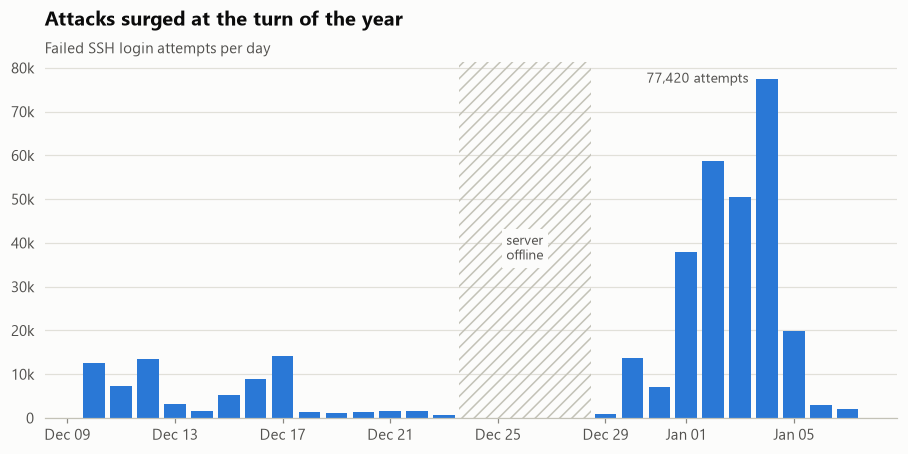

Median per online day: 6,136 | Jan 1-4 total: 224,706 (65% of all attempts)


In [3]:
daily = failed.set_index("timestamp").resample("D").size()
all_days = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(all_days, fill_value=0)
offline = (all_days > "2017-12-23") & (all_days < "2017-12-29")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(daily.index[~offline], daily[~offline], width=0.8, color=BLUE)
# Bars are centered on midnight, so the offline days (Dec 24-28) span Dec 23 ~14h to Dec 28 ~10h.
ax.axvspan(
    pd.Timestamp("2017-12-23 13:00"),
    pd.Timestamp("2017-12-28 11:00"),
    facecolor="none",
    edgecolor=GRAY,
    hatch="///",
    linewidth=0,
)
ax.text(
    pd.Timestamp("2017-12-26"),
    daily.max() * 0.5,
    "server\noffline",
    ha="center",
    va="center",
    color=INK_2,
    fontsize=9,
    bbox=dict(facecolor=SURFACE, edgecolor="none", pad=3),
)

peak_day = daily.idxmax()
ax.annotate(
    f"{daily.max():,} attempts",
    xy=(peak_day, daily.max()),
    xytext=(-12, 0),
    textcoords="offset points",
    ha="right",
    va="center",
    color=INK_2,
    fontsize=9,
)

ax.yaxis.set_major_formatter(thousands)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Attacks surged at the turn of the year")
subtitle(ax, "Failed SSH login attempts per day")
fig.savefig(FIGURES / "attempts_per_day.png")
plt.show()

online = daily[~offline]
print(
    f"Median per online day: {online.median():,.0f} | Jan 1-4 total: {daily['2018-01-01':'2018-01-04'].sum():,} "
    f"({daily['2018-01-01':'2018-01-04'].sum() / daily.sum():.0%} of all attempts)"
)

## 2. Time of day

Server time (the log has no timezone). If the bots were humans typing, we would expect a daily rhythm.

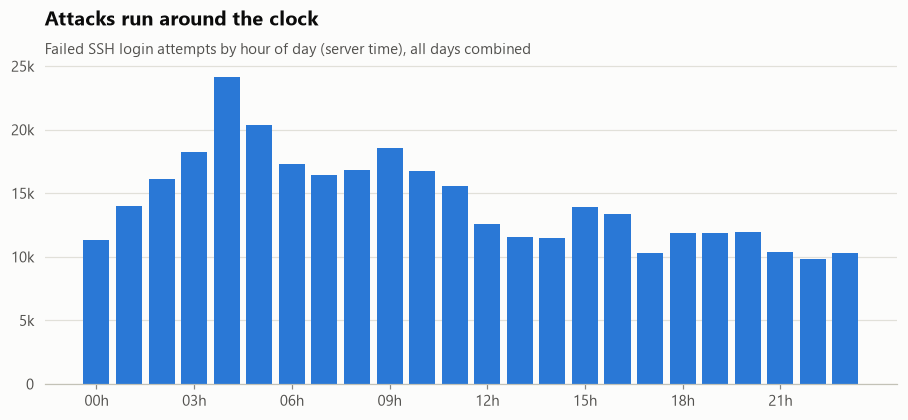

Busiest hour: 04h (24,112) | quietest: 22h (9,839) | ratio 2.5x


In [4]:
hourly = failed["timestamp"].dt.hour.value_counts().reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(hourly.index, hourly.values, width=0.8, color=BLUE)
ax.set_xticks(range(0, 24, 3), [f"{h:02d}h" for h in range(0, 24, 3)])
ax.yaxis.set_major_formatter(thousands)
ax.set_title("Attacks run around the clock")
subtitle(ax, "Failed SSH login attempts by hour of day (server time), all days combined")
fig.savefig(FIGURES / "attempts_by_hour.png")
plt.show()

print(
    f"Busiest hour: {hourly.idxmax():02d}h ({hourly.max():,}) | quietest: {hourly.idxmin():02d}h ({hourly.min():,}) "
    f"| ratio {hourly.max() / hourly.min():.1f}x"
)

Hourly totals are dominated by a few heavy IPs running for days, so a single bot can create a "peak hour". Counting **distinct IPs active per hour** shows whether the *number of attackers* changes during the day.

In [5]:
ips_per_hour = (
    failed.assign(hour=failed["timestamp"].dt.hour).groupby("hour")["ip"].nunique().reindex(range(24), fill_value=0)
)
print(
    f"Distinct attacking IPs per hour: min {ips_per_hour.min()}, median {ips_per_hour.median():.0f}, max {ips_per_hour.max()}"
)
print(
    f"Attempts per hour vary {hourly.max() / hourly.min():.1f}x; distinct IPs per hour vary {ips_per_hour.max() / ips_per_hour.min():.1f}x"
)

Distinct attacking IPs per hour: min 82, median 102, max 128
Attempts per hour vary 2.5x; distinct IPs per hour vary 1.6x


## 3. Targeted usernames

Only failed password attempts. Legitimate users of the lab server are not shown.

root: 94.0% of attempts | 1,747 distinct usernames tried


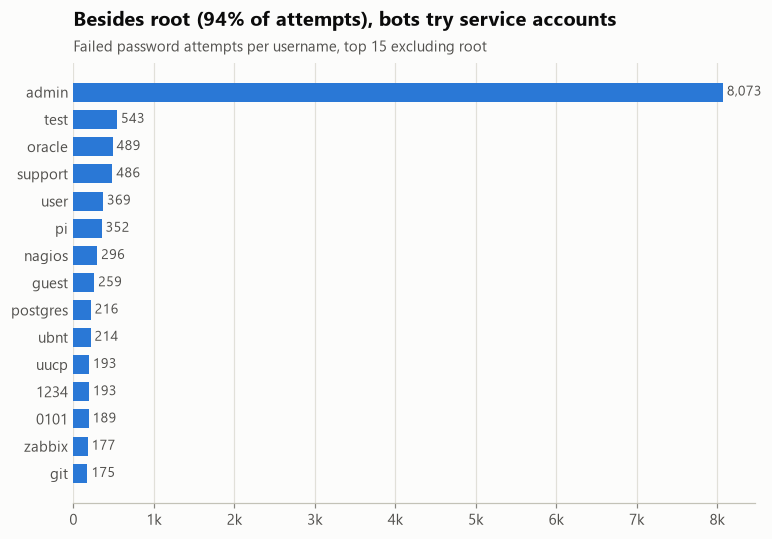

In [6]:
pw_failed = failed[failed["method"] == "password"]
users = pw_failed["username"].value_counts()
share = users / users.sum()

print(f"root: {share['root']:.1%} of attempts | {users.size:,} distinct usernames tried")
top_rest = users.drop("root").head(15)

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(top_rest.index[::-1], top_rest.values[::-1], height=0.7, color=BLUE)
for y, v in enumerate(top_rest.values[::-1]):
    ax.text(v, y, f" {v:,}", va="center", color=INK_2, fontsize=9)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(thousands)
ax.tick_params(axis="y", length=0)
ax.set_title(f"Besides root ({share['root']:.0%} of attempts), bots try service accounts")
subtitle(ax, "Failed password attempts per username, top 15 excluding root")
fig.savefig(FIGURES / "top_usernames.png")
plt.show()

Invalid usernames (that do not exist on the server) vs existing ones: an attempt on an invalid user can never succeed, so it is pure noise.

In [7]:
pw_failed["invalid_user"].map({0: "existing user", 1: "invalid user"}).value_counts(normalize=True).round(3)

invalid_user
existing user    0.942
invalid user     0.058
Name: proportion, dtype: float64

## 4. How concentrated are the attacks?

Sort IPs from most to least active and accumulate their share of all failed attempts.

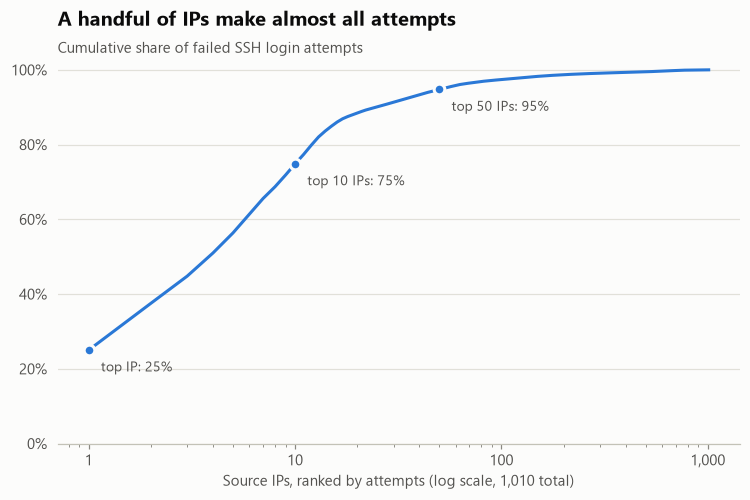

In [8]:
per_ip = failed["ip"].value_counts()
cum_share = per_ip.cumsum() / per_ip.sum()
rank = range(1, len(per_ip) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rank, cum_share.values * 100, color=BLUE, linewidth=2)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, 102)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False)
for n in (1, 10, 50):
    y = cum_share.iloc[n - 1] * 100
    ax.plot(n, y, "o", color=BLUE, markersize=7, markeredgecolor=SURFACE, markeredgewidth=2)
    label = "top IP" if n == 1 else f"top {n} IPs"
    ax.annotate(f"{label}: {y:.0f}%", xy=(n, y), xytext=(8, -14), textcoords="offset points", color=INK_2, fontsize=9)
ax.set_xlabel(f"Source IPs, ranked by attempts (log scale, {len(per_ip):,} total)")
ax.set_title("A handful of IPs make almost all attempts")
subtitle(ax, "Cumulative share of failed SSH login attempts")
fig.savefig(FIGURES / "ip_concentration.png")
plt.show()

In [9]:
top_ips = (
    failed.groupby("ip")
    .agg(
        attempts=("ip", "size"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
        usernames=("username", "nunique"),
    )
    .sort_values("attempts", ascending=False)
    .head(10)
    .merge(countries.set_index("ip")[["country_name"]], left_index=True, right_index=True, how="left")
)
top_ips["hours_active"] = ((top_ips["last_seen"] - top_ips["first_seen"]).dt.total_seconds() / 3600).round(1)
top_ips["per_minute"] = (top_ips["attempts"] / (top_ips["hours_active"] * 60)).round(1)
top_ips.index = top_ips.index.map(mask_ip)
top_ips[["country_name", "attempts", "usernames", "first_seen", "last_seen", "hours_active", "per_minute"]]

,country_name,attempts,usernames,first_seen,last_seen,hours_active,per_minute
ip,,,,,,,
59.63.188.x,China,86294,1,2018-01-03 10:07:06,2018-01-05 12:22:59,50.3,28.6
58.242.83.x,China,43147,1,2018-01-01 08:48:42,2018-01-02 17:13:42,32.4,22.2
218.65.30.x,China,25102,1,2018-01-01 14:23:31,2018-01-02 11:12:24,20.8,20.1
218.87.109.x,China,21377,1,2018-01-03 15:01:58,2018-01-04 12:17:10,21.3,16.7
182.100.67.x,China,18513,1,2018-01-01 20:32:23,2018-01-02 11:31:34,15.0,20.6
183.63.110.x,China,17340,1,2018-01-02 19:15:56,2018-01-03 10:08:41,14.9,19.4
183.238.178.x,China,14519,1,2017-12-12 02:13:17,2017-12-16 21:22:03,115.1,2.1
183.62.140.x,China,10852,51,2017-12-10 10:54:29,2017-12-10 17:19:17,6.4,28.3
139.219.191.x,China,10852,51,2017-12-30 04:23:07,2017-12-30 11:33:57,7.2,25.1


## 5. Countries

Country of the IP according to DB-IP (today's data, not 2017's). This is where the infrastructure is registered, not where the attacker sits: compromised machines, cloud servers and proxies are the norm.

In [10]:
geo = failed.merge(countries, on="ip", how="left")
missing = geo["country_code"].isna().mean()
by_country = (
    geo.groupby("country_name")
    .agg(attempts=("ip", "size"), ips=("ip", "nunique"))
    .sort_values("attempts", ascending=False)
)
by_country["share"] = by_country["attempts"] / by_country["attempts"].sum()
print(f"{by_country.shape[0]} countries | IPs without a country: {missing:.1%} of attempts")
by_country.head(10)

72 countries | IPs without a country: 0.0% of attempts


,attempts,ips,share
country_name,,,
China,324386,316,0.940078
Ukraine,3089,7,0.008952
Russia,2795,51,0.008100
Vietnam,2260,71,0.006550
South Korea,1968,61,0.005703
United States,1610,71,0.004666
France,1413,57,0.004095
Iran,1000,14,0.002898
United Kingdom,884,15,0.002562


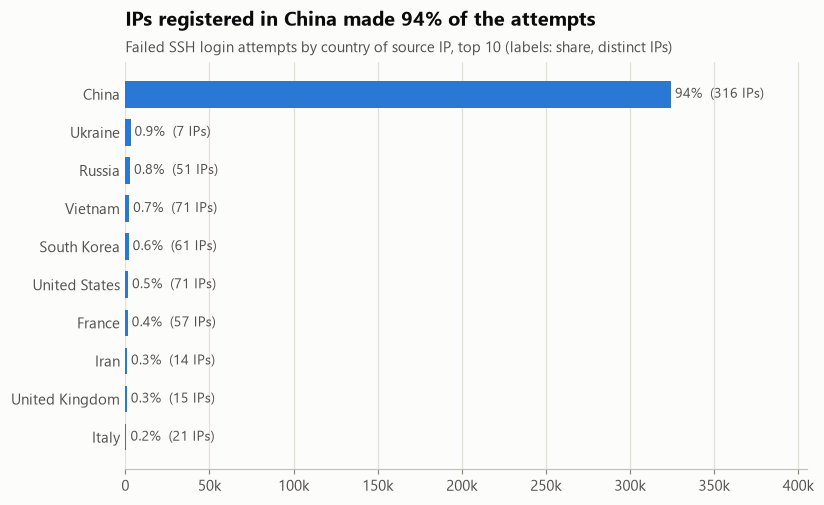

In [11]:
top_c = by_country.head(10)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(top_c.index[::-1], top_c["attempts"].values[::-1], height=0.7, color=BLUE)
for y, (a, s, n) in enumerate(zip(top_c["attempts"][::-1], top_c["share"][::-1], top_c["ips"][::-1])):
    ax.text(a, y, f" {pct(s)}  ({n} IPs)", va="center", color=INK_2, fontsize=9)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(thousands)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, top_c["attempts"].max() * 1.25)
lead = top_c.index[0]
ax.set_title(f"IPs registered in {lead} made {top_c['share'].iloc[0]:.0%} of the attempts")
subtitle(ax, "Failed SSH login attempts by country of source IP, top 10 (labels: share, distinct IPs)")
fig.savefig(FIGURES / "top_countries.png")
plt.show()

## Takeaways

1. **Volume is bursty, not steady.** The median online day had ~6k failed attempts, but Jan 1-4 alone produced 65% of the 28 days' total.
2. **There is no real "peak hour".** Attempts per hour vary 2.5x, but the number of distinct attacking IPs per hour stays between 82 and 128. The same population attacks all day; peaks come from a few fast bots.
3. **The heaviest attackers are single-target bots.** The top 7 IPs tried only `root`, at 20-28 attempts per minute for 15-50 hours straight.
4. **Same tool, different IPs.** Two IPs made exactly 10,852 attempts over 51 usernames, three weeks apart: almost certainly the same tool and wordlist.
5. **Volume is not headcount.** IPs registered in China are 316 of 1,010 sources but 94% of attempts; Vietnam has 71 IPs and under 1%.
6. **94% of attempts target usernames that exist** (mostly `root`). Disabling root login over SSH would turn almost all of them into guaranteed failures.

Next: a detection rule for brute force and a replay of the log through `fail2ban`'s logic.